# Diabetes Prediction System


## Buoc 1: Import thu vien

**Giải thích:** Cell này nạp các thư viện dùng để xử lý dữ liệu, trực quan hóa, huấn luyện/đánh giá mô hình và lưu mô hình. Đồng thời tắt các cảnh báo không cần thiết để kết quả hiển thị gọn hơn.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve
)
import pickle
import csv
import warnings
warnings.filterwarnings('ignore')
print('All libraries imported successfully!')

All libraries imported successfully!


## Buoc 2: Tai va kham pha du lieu

**Giải thích:** Đọc bộ dữ liệu CSV vào DataFrame `df`, in kích thước và tên các cột, sau đó xem 10 dòng đầu tiên để kiểm tra dữ liệu đã được tải đúng.

In [2]:
# Doc file CSV - doi ten file cho phu hop voi file cua ban
df = pd.read_csv('../data/raw/diabetes.csv')

print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'\nColumn names: {df.columns.tolist()}')
df.head(10)

Dataset shape: 100000 rows x 9 columns

Column names: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


**Giải thích:** Khảo sát kiểu dữ liệu, các thống kê mô tả, số giá trị thiếu và tỷ lệ hai lớp nhãn `diabetes`. Việc này giúp phát hiện vấn đề chất lượng dữ liệu và mức mất cân bằng lớp.

In [3]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Descriptive Statistics ===')
display(df.describe())
print('\n=== Null Values ===')
print(df.isnull().sum())
print('\n=== Diabetes Distribution ===')
print(df['diabetes'].value_counts())
no_count  = df['diabetes'].value_counts()[0]
yes_count = df['diabetes'].value_counts()[1]
total     = len(df)
print(f'  0 = No Diabetes: {no_count}  ({no_count/total*100:.1f}%)')
print(f'  1 = Diabetes:    {yes_count}  ({yes_count/total*100:.1f}%)')

=== Data Types ===
gender                     str
age                    float64
hypertension             int64
heart_disease            int64
smoking_history            str
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

=== Descriptive Statistics ===


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000



=== Null Values ===
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

=== Diabetes Distribution ===
diabetes
0    91500
1     8500
Name: count, dtype: int64
  0 = No Diabetes: 91500  (91.5%)
  1 = Diabetes:    8500  (8.5%)


**Giải thích:** Liệt kê các giá trị khác nhau trong hai biến phân loại `gender` và `smoking_history` để chuẩn bị cho bước mã hóa.

In [4]:
print('=== Categorical column values ===')
print('gender unique values:         ', df['gender'].unique())
print('smoking_history unique values:', df['smoking_history'].unique())

=== Categorical column values ===
gender unique values:          <ArrowStringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str
smoking_history unique values: <ArrowStringArray>
['never', 'No Info', 'current', 'former', 'ever', 'not current']
Length: 6, dtype: str


## Buoc 3: Truc quan hoa du lieu

**Giải thích:** Tạo bốn biểu đồ khám phá dữ liệu: tỷ lệ nhãn, phân phối đường huyết và BMI theo nhãn, cùng mối quan hệ giữa tuổi và đường huyết. Hình được lưu tại `data/processed/analysis.png`.

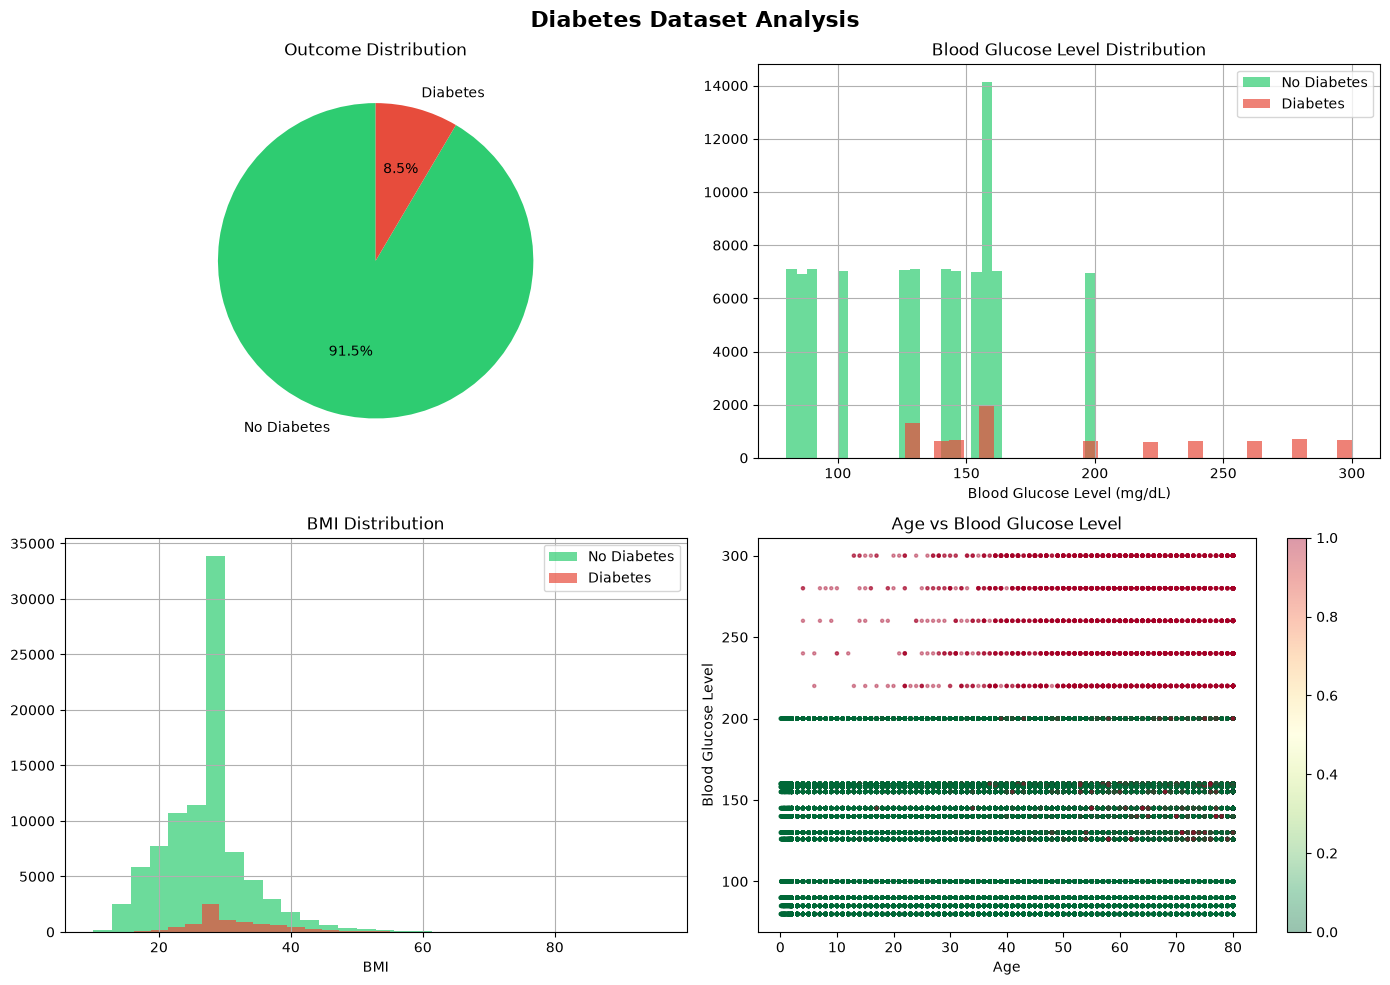

Chart saved: ../data/processed/analysis.png


In [5]:
os.makedirs('../data/processed', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Diabetes Dataset Analysis', fontsize=16, fontweight='bold')

# 1. Pie chart phan phoi nhan (diabetes)
outcome_counts = df['diabetes'].value_counts().sort_index()
axes[0, 0].pie(
    outcome_counts.values,
    labels=['No Diabetes', 'Diabetes'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
)
axes[0, 0].set_title('Outcome Distribution')

# 2. Histogram blood_glucose_level theo nhan
df[df['diabetes'] == 0]['blood_glucose_level'].hist(
    ax=axes[0, 1], alpha=0.7, color='#2ecc71', label='No Diabetes', bins=30
)
df[df['diabetes'] == 1]['blood_glucose_level'].hist(
    ax=axes[0, 1], alpha=0.7, color='#e74c3c', label='Diabetes', bins=30
)
axes[0, 1].set_title('Blood Glucose Level Distribution')
axes[0, 1].set_xlabel('Blood Glucose Level (mg/dL)')
axes[0, 1].legend()

# 3. Histogram BMI theo nhan
df[df['diabetes'] == 0]['bmi'].hist(
    ax=axes[1, 0], alpha=0.7, color='#2ecc71', label='No Diabetes', bins=30
)
df[df['diabetes'] == 1]['bmi'].hist(
    ax=axes[1, 0], alpha=0.7, color='#e74c3c', label='Diabetes', bins=30
)
axes[1, 0].set_title('BMI Distribution')
axes[1, 0].set_xlabel('BMI')
axes[1, 0].legend()

# 4. Scatter: age vs blood_glucose_level
scatter = axes[1, 1].scatter(
    df['age'],
    df['blood_glucose_level'],
    c=df['diabetes'],
    cmap='RdYlGn_r',
    alpha=0.4,
    s=5,
)
axes[1, 1].set_title('Age vs Blood Glucose Level')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Blood Glucose Level')
plt.colorbar(scatter, ax=axes[1, 1])

plt.tight_layout()
plt.savefig('../data/processed/analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: ../data/processed/analysis.png')

**Giải thích:** Chọn các cột số, tính ma trận tương quan và hiển thị dưới dạng heatmap. Biểu đồ giúp nhận biết các đặc trưng có quan hệ tuyến tính mạnh với nhau hoặc với nhãn.

Numeric columns used for correlation: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


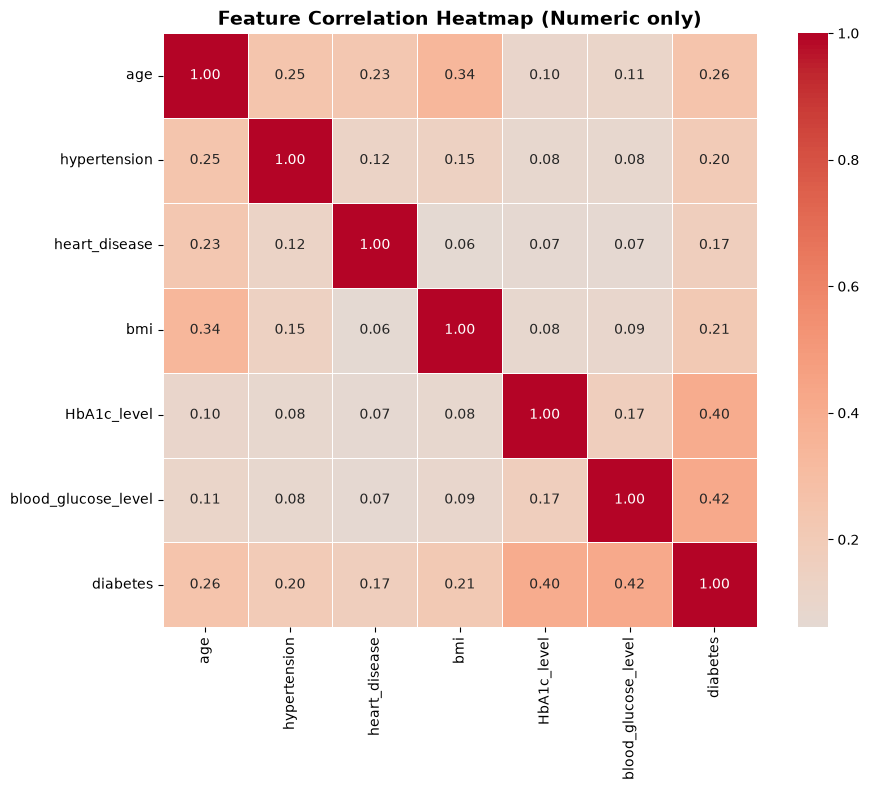

Heatmap saved: ../data/processed/heatmap.png


In [6]:
os.makedirs('../data/processed', exist_ok=True)

# Heatmap tuong quan - chi dung cot so (numeric)
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
print('Numeric columns used for correlation:', numeric_cols)
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title('Feature Correlation Heatmap (Numeric only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved: ../data/processed/heatmap.png')

**Giải thích:** Vẽ boxplot của HbA1c, đường huyết và BMI theo trạng thái tiểu đường để so sánh trung vị, độ phân tán và các ngoại lệ giữa hai nhóm.

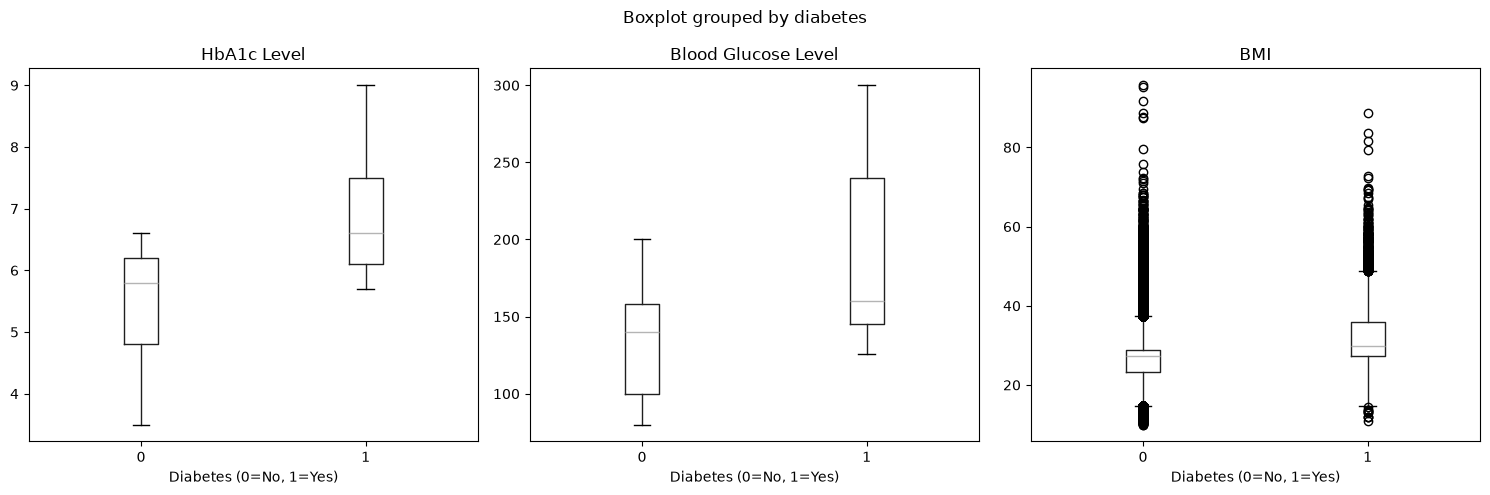

Boxplots saved: ../data/processed/boxplots.png


In [7]:
os.makedirs('../data/processed', exist_ok=True)

# Boxplot HbA1c_level theo diabetes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Key Features by Diabetes Status', fontweight='bold')

df.boxplot(column='HbA1c_level',   by='diabetes', ax=axes[0], grid=False)
df.boxplot(column='blood_glucose_level', by='diabetes', ax=axes[1], grid=False)
df.boxplot(column='bmi',           by='diabetes', ax=axes[2], grid=False)

axes[0].set_title('HbA1c Level')
axes[1].set_title('Blood Glucose Level')
axes[2].set_title('BMI')

for ax in axes:
    ax.set_xlabel('Diabetes (0=No, 1=Yes)')

plt.tight_layout()
plt.savefig('../data/processed/boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Boxplots saved: ../data/processed/boxplots.png')

## Buoc 4: Tien xu ly du lieu

**Giải thích:** Sao chép dữ liệu gốc để bảo toàn `df`, rồi dùng `LabelEncoder` chuyển hai biến phân loại thành số. Bảng ánh xạ được in ra để có thể kiểm tra cách mã hóa.

In [8]:
df_processed = df.copy()

# 4.1 Encode 'gender': Female=0, Male=1, Other=2
le_gender = LabelEncoder()
df_processed['gender'] = le_gender.fit_transform(df_processed['gender'].astype(str))
print('gender encoding:', dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))

# 4.2 Encode 'smoking_history': never=0, No Info=1, current=2, former=3, ever=4, not current=5
le_smoke = LabelEncoder()
df_processed['smoking_history'] = le_smoke.fit_transform(df_processed['smoking_history'].astype(str))
print('smoking_history encoding:', dict(zip(le_smoke.classes_, le_smoke.transform(le_smoke.classes_))))

print('\nProcessed dtypes:')
print(df_processed.dtypes)
print('\nSample:')
display(df_processed.head())

gender encoding: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
smoking_history encoding: {'No Info': np.int64(0), 'current': np.int64(1), 'ever': np.int64(2), 'former': np.int64(3), 'never': np.int64(4), 'not current': np.int64(5)}

Processed dtypes:
gender                   int64
age                    float64
hypertension             int64
heart_disease            int64
smoking_history          int64
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Sample:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


**Giải thích:** Xác định 8 đặc trưng đầu vào (`X`) và nhãn dự đoán (`y`), chia dữ liệu train/test theo tỷ lệ 80/20 có giữ tỷ lệ lớp, rồi chuẩn hóa dữ liệu. Scaler chỉ được `fit` trên tập train để tránh rò rỉ dữ liệu.

In [9]:
# 4.3 Tach features va label
FEATURE_COLS = ['gender', 'age', 'hypertension', 'heart_disease',
                'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
LABEL_COL    = 'diabetes'

X = df_processed[FEATURE_COLS]
y = df_processed[LABEL_COL]

print(f'Features: {FEATURE_COLS}')
print(f'Label:    {LABEL_COL}  (0=No, 1=Yes)')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

# 4.4 Train / Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain samples: {X_train.shape[0]}')
print(f'Test  samples: {X_test.shape[0]}')

# 4.5 Chuan hoa (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('\nStandardScaler applied!')

Features: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Label:    diabetes  (0=No, 1=Yes)
X shape: (100000, 8)
y shape: (100000,)

Train samples: 80000
Test  samples: 20000

StandardScaler applied!


## Buoc 5: Huan luyen mo hinh Logistic Regression voi model.fit()

**Giải thích:** Khởi tạo Logistic Regression và gọi `model.fit()` để học từ dữ liệu train đã chuẩn hóa. Sau khi huấn luyện, cell hiển thị số đặc trưng, các lớp và số vòng lặp để hội tụ.

In [10]:
model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')

print('Training model...')
print('=' * 50)

# ===========================
#   GOI HAM fit() O DAY
# ===========================
model.fit(X_train_scaled, y_train)

print('model.fit() completed successfully!')
print('=' * 50)
print(f'Number of features:      {model.n_features_in_}')
print(f'Classes:                 {model.classes_}')
print(f'Iterations to converge:  {model.n_iter_[0]}')

Training model...
model.fit() completed successfully!
Number of features:      8
Classes:                 [0 1]
Iterations to converge:  12


**Giải thích:** Trích xuất hệ số của Logistic Regression, sắp xếp theo độ lớn tuyệt đối và vẽ biểu đồ. Hệ số dương làm tăng xác suất lớp tiểu đường; hệ số âm làm giảm xác suất, trong phạm vi dữ liệu đã chuẩn hóa.

Feature Importance (by coefficient magnitude):
            Feature  Coefficient  Abs_Coefficient
        HbA1c_level     2.498802         2.498802
blood_glucose_level     1.365197         1.365197
                age     1.015374         1.015374
                bmi     0.600290         0.600290
       hypertension     0.209272         0.209272
    smoking_history     0.194100         0.194100
             gender     0.154626         0.154626
      heart_disease     0.151941         0.151941


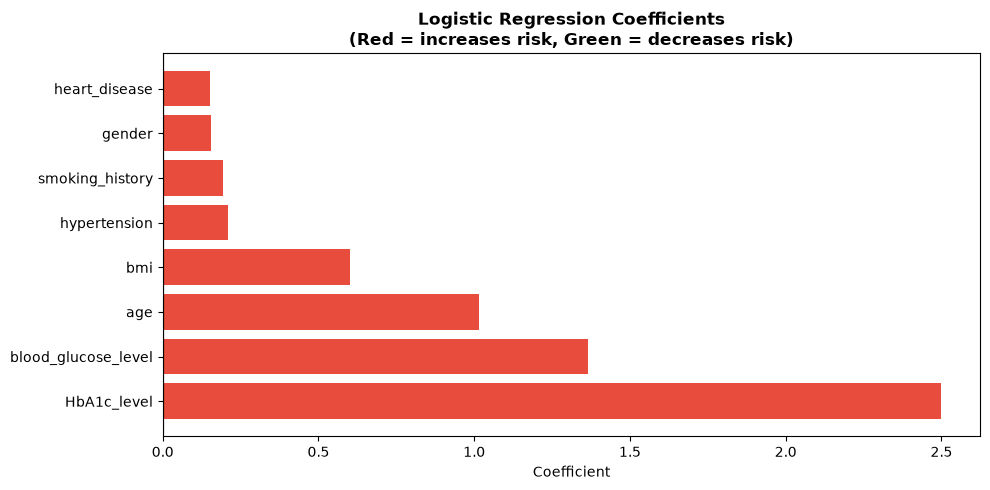

Chart saved: ../data/processed/coefficients.png


In [11]:
os.makedirs('../data/processed', exist_ok=True)

coef_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Coefficient': model.coef_[0],
    'Abs_Coefficient': np.abs(model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print('Feature Importance (by coefficient magnitude):')
print(coef_df.to_string(index=False))

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients\n(Red = increases risk, Green = decreases risk)', fontweight='bold')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.savefig('../data/processed/coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: ../data/processed/coefficients.png')

## Buoc 6: Danh gia mo hinh

**Giải thích:** Dự đoán nhãn và xác suất trên tập test, sau đó tính Accuracy và ROC-AUC. Báo cáo phân loại bổ sung precision, recall và F1-score cho từng lớp.

In [12]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_prob)

print('=' * 55)
print('          MODEL EVALUATION RESULTS')
print('=' * 55)
print(f'  Accuracy:  {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  ROC-AUC:   {roc_auc:.4f}')
print('=' * 55)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

          MODEL EVALUATION RESULTS
  Accuracy:  0.9603  (96.03%)
  ROC-AUC:   0.9620

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.97      0.99      0.98     18300
    Diabetes       0.86      0.64      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.91      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000



**Giải thích:** Minh họa chất lượng Logistic Regression bằng confusion matrix và ROC curve. Các biểu đồ này được lưu vào `data/processed/evaluation.png`.

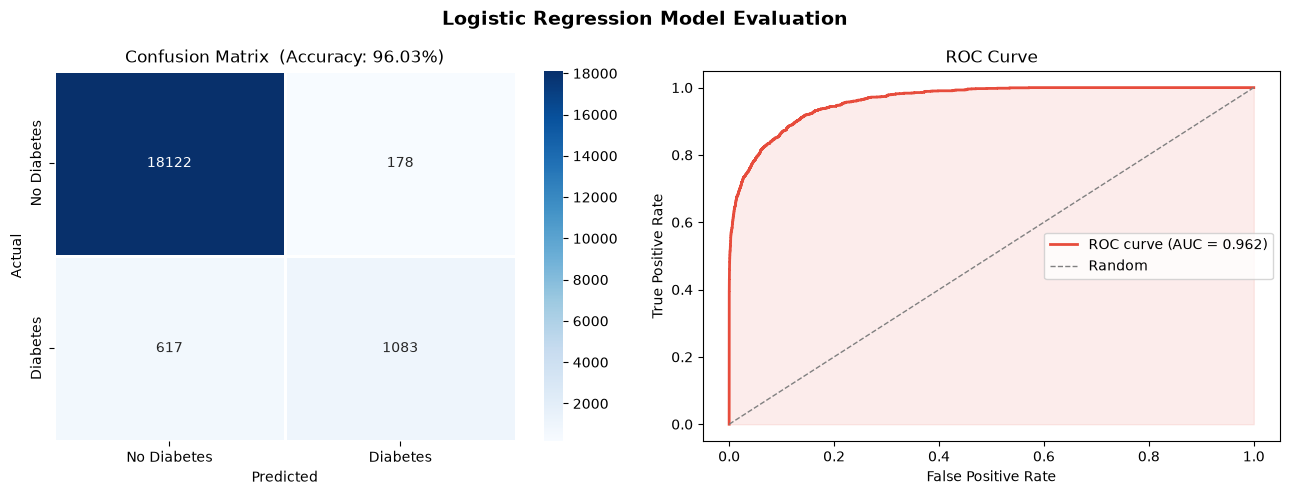

Chart saved: ../data/processed/evaluation.png


In [13]:
os.makedirs('../data/processed', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Logistic Regression Model Evaluation', fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes'],
    ax=axes[0], linewidths=2
)
axes[0].set_title(f'Confusion Matrix  (Accuracy: {accuracy:.2%})')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: ../data/processed/evaluation.png')

## Buoc 5b: Huan luyen them 4 mo hinh hoc may voi model.fit()
### Mo hinh 2: Random Forest | Mo hinh 3: SVM | Mo hinh 4: KNN | Mo hinh 5: Decision Tree

**Giải thích:** Nhập các lớp mô hình bổ sung: Random Forest, SVM, KNN và Decision Tree để so sánh với Logistic Regression.

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
print('Extra model libraries imported!')


Extra model libraries imported!


### Mo hinh 2: Random Forest Classifier

**Giải thích:** Huấn luyện Random Forest gồm 100 cây, sau đó dự đoán trên tập test và báo cáo Accuracy, ROC-AUC cùng các chỉ số phân loại.

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

print('[Random Forest] Training...')
rf_model.fit(X_train_scaled, y_train)
print('[Random Forest] model.fit() done!')

rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]
rf_acc  = accuracy_score(y_test, rf_pred)
rf_auc  = roc_auc_score(y_test, rf_prob)

print('=' * 50)
print('  Accuracy : {:.4f}  ({:.2f}%)'.format(rf_acc, rf_acc * 100))
print('  ROC-AUC  : {:.4f}'.format(rf_auc))
print('=' * 50)
print(classification_report(y_test, rf_pred, target_names=['No Diabetes', 'Diabetes']))


[Random Forest] Training...
[Random Forest] model.fit() done!
  Accuracy : 0.9722  (97.22%)
  ROC-AUC  : 0.9720
              precision    recall  f1-score   support

 No Diabetes       0.97      1.00      0.99     18300
    Diabetes       1.00      0.67      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.98      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000



### Mo hinh 3: Support Vector Machine (SVM)

**Giải thích:** Huấn luyện SVM với kernel RBF để mô hình hóa ranh giới quyết định phi tuyến, rồi đánh giá trên cùng tập test. Trên dữ liệu lớn, cell này có thể mất nhiều thời gian hơn.

In [16]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    probability=True,
    random_state=42
)

print('[SVM] Training... (may take a while on large datasets)')
svm_model.fit(X_train_scaled, y_train)
print('[SVM] model.fit() done!')

svm_pred = svm_model.predict(X_test_scaled)
svm_prob = svm_model.predict_proba(X_test_scaled)[:, 1]
svm_acc  = accuracy_score(y_test, svm_pred)
svm_auc  = roc_auc_score(y_test, svm_prob)

print('=' * 50)
print('  Accuracy : {:.4f}  ({:.2f}%)'.format(svm_acc, svm_acc * 100))
print('  ROC-AUC  : {:.4f}'.format(svm_auc))
print('=' * 50)
print(classification_report(y_test, svm_pred, target_names=['No Diabetes', 'Diabetes']))


[SVM] Training... (may take a while on large datasets)
[SVM] model.fit() done!
  Accuracy : 0.9645  (96.45%)
  ROC-AUC  : 0.9335
              precision    recall  f1-score   support

 No Diabetes       0.96      1.00      0.98     18300
    Diabetes       0.97      0.60      0.74      1700

    accuracy                           0.96     20000
   macro avg       0.97      0.80      0.86     20000
weighted avg       0.96      0.96      0.96     20000



### Mo hinh 4: K-Nearest Neighbors (KNN)

**Giải thích:** Huấn luyện KNN với 7 láng giềng gần nhất theo khoảng cách Euclidean và đánh giá khả năng dự đoán. Vì KNN dựa vào khoảng cách, dữ liệu chuẩn hóa ở bước trước là cần thiết.

In [17]:
knn_model = KNeighborsClassifier(
    n_neighbors=7,
    metric='euclidean',
    weights='uniform'
)

print('[KNN] Training...')
knn_model.fit(X_train_scaled, y_train)
print('[KNN] model.fit() done!')

knn_pred = knn_model.predict(X_test_scaled)
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]
knn_acc  = accuracy_score(y_test, knn_pred)
knn_auc  = roc_auc_score(y_test, knn_prob)

print('=' * 50)
print('  Accuracy : {:.4f}  ({:.2f}%)'.format(knn_acc, knn_acc * 100))
print('  ROC-AUC  : {:.4f}'.format(knn_auc))
print('=' * 50)
print(classification_report(y_test, knn_pred, target_names=['No Diabetes', 'Diabetes']))


[KNN] Training...
[KNN] model.fit() done!
  Accuracy : 0.9623  (96.23%)
  ROC-AUC  : 0.9195
              precision    recall  f1-score   support

 No Diabetes       0.97      0.99      0.98     18300
    Diabetes       0.90      0.62      0.74      1700

    accuracy                           0.96     20000
   macro avg       0.93      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000



### Mo hinh 5: Decision Tree Classifier

**Giải thích:** Huấn luyện Decision Tree với các giới hạn độ sâu và số mẫu để giảm overfitting, rồi tính các chỉ số đánh giá trên tập test.

In [18]:
dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

print('[Decision Tree] Training...')
dt_model.fit(X_train_scaled, y_train)
print('[Decision Tree] model.fit() done!')

dt_pred = dt_model.predict(X_test_scaled)
dt_prob = dt_model.predict_proba(X_test_scaled)[:, 1]
dt_acc  = accuracy_score(y_test, dt_pred)
dt_auc  = roc_auc_score(y_test, dt_prob)

print('=' * 50)
print('  Accuracy : {:.4f}  ({:.2f}%)'.format(dt_acc, dt_acc * 100))
print('  ROC-AUC  : {:.4f}'.format(dt_auc))
print('=' * 50)
print(classification_report(y_test, dt_pred, target_names=['No Diabetes', 'Diabetes']))


[Decision Tree] Training...
[Decision Tree] model.fit() done!
  Accuracy : 0.9720  (97.20%)
  ROC-AUC  : 0.9738
              precision    recall  f1-score   support

 No Diabetes       0.97      1.00      0.98     18300
    Diabetes       0.98      0.68      0.81      1700

    accuracy                           0.97     20000
   macro avg       0.98      0.84      0.90     20000
weighted avg       0.97      0.97      0.97     20000



### Bang so sanh ket qua 5 mo hinh

**Giải thích:** Tổng hợp Accuracy và ROC-AUC của cả năm mô hình, sắp xếp theo ROC-AUC để xác định mô hình tốt nhất theo thước đo này.

In [19]:
lr_acc = accuracy_score(y_test, model.predict(X_test_scaled))
lr_auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])

comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest      ',
        'SVM (RBF kernel)   ',
        'KNN (k=7)          ',
        'Decision Tree      '
    ],
    'Accuracy (%)': [
        round(lr_acc  * 100, 2),
        round(rf_acc  * 100, 2),
        round(svm_acc * 100, 2),
        round(knn_acc * 100, 2),
        round(dt_acc  * 100, 2)
    ],
    'ROC-AUC': [
        round(lr_auc,  4),
        round(rf_auc,  4),
        round(svm_auc, 4),
        round(knn_auc, 4),
        round(dt_auc,  4)
    ]
})

comparison = comparison.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
comparison.index = comparison.index + 1

print('=' * 52)
print('       SO SANH 5 MO HINH HOC MAY')
print('=' * 52)
print(comparison.to_string())
print('=' * 52)
best_model = comparison.iloc[0]['Model'].strip()
best_acc   = comparison.iloc[0]['Accuracy (%)']
best_auc   = comparison.iloc[0]['ROC-AUC']
print('Best model : {}'.format(best_model))
print('Accuracy   : {}%'.format(best_acc))
print('ROC-AUC    : {}'.format(best_auc))


       SO SANH 5 MO HINH HOC MAY
                 Model  Accuracy (%)  ROC-AUC
1  Decision Tree               97.20   0.9738
2  Random Forest               97.22   0.9720
3  Logistic Regression         96.03   0.9620
4  SVM (RBF kernel)            96.45   0.9335
5  KNN (k=7)                   96.23   0.9195
Best model : Decision Tree
Accuracy   : 97.2%
ROC-AUC    : 0.9738


## Buoc 7: Luu mo hinh va encoder

**Giải thích:** Lưu Logistic Regression, scaler và hai encoder bằng `pickle`. Các tệp này được API dùng để tái tạo đúng quy trình tiền xử lý và dự đoán sau này.

In [20]:
os.makedirs('../models', exist_ok=True)

with open('../models/model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../models/le_gender.pkl', 'wb') as f:
    pickle.dump(le_gender, f)

with open('../models/le_smoke.pkl', 'wb') as f:
    pickle.dump(le_smoke, f)

print('Saved: ../models/model.pkl     (LogisticRegression)')
print('Saved: ../models/scaler.pkl    (StandardScaler)')
print('Saved: ../models/le_gender.pkl (LabelEncoder for gender)')
print('Saved: ../models/le_smoke.pkl  (LabelEncoder for smoking_history)')
print('\nFeature columns:', FEATURE_COLS)

Saved: ../models/model.pkl     (LogisticRegression)
Saved: ../models/scaler.pkl    (StandardScaler)
Saved: ../models/le_gender.pkl (LabelEncoder for gender)
Saved: ../models/le_smoke.pkl  (LabelEncoder for smoking_history)

Feature columns: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
